In [1]:
# =========================================================
# PROJET DE DETECTION DE PNEUMONIE
# TRANSFER LEARNING AVEC DenseNet121
# =========================================================

import tensorflow as tf

import numpy as np

import matplotlib.pyplot as plt

import os

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (

    Dense,

    Dropout,

    GlobalAveragePooling2D,

    Input
)


# =========================================================
# IMPORTATION DU MODELE PREENTRAINE
# =========================================================

from tensorflow.keras.applications import DenseNet121


# =========================================================
# IMPORTATION DES CALLBACKS
# =========================================================

from tensorflow.keras.callbacks import (

    EarlyStopping,

    ModelCheckpoint
)


# =========================================================
# IMPORTATION DES METRIQUES
# =========================================================

from tensorflow.keras.metrics import (

    Precision,

    Recall,

    AUC
)



print("\n========== VERSION TENSORFLOW ==========\n")

print(tf.__version__)


print("\n========== GPU DISPONIBLE ==========\n")

print(tf.config.list_physical_devices('GPU'))


print("\nEnvironnement DenseNet121 prêt avec succès !")


========== VERSION TENSORFLOW ==========

2.20.0

========== GPU DISPONIBLE ==========

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Environnement DenseNet121 prêt avec succès !


In [2]:
# =========================================================
# MONTAGE DE GOOGLE DRIVE
# =========================================================

from google.colab import drive


# =========================================================
# MONTAGE DU DRIVE
# =========================================================

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =========================================================
# DECOMPRESSION DU DATASET
# =========================================================

import zipfile


# =========================================================
# CHEMIN DU FICHIER ZIP
# =========================================================

zip_path = "/content/drive/MyDrive/archive (1).zip"


# =========================================================
# DOSSIER DE DESTINATION
# =========================================================

extract_path = "/content/"


# =========================================================
# DECOMPRESSION
# =========================================================

with zipfile.ZipFile(

    zip_path,

    'r'
) as zip_ref:

    zip_ref.extractall(

        extract_path
    )

print("Dataset décompressé avec succès !")

Dataset décompressé avec succès !


In [4]:
# =========================================================
# CHARGEMENT DES DATASETS
# POUR DenseNet121
# =========================================================
dataset_path = "/content/chest_xray/chest_xray"
# =========================================================
# DOSSIER TRAIN
# =========================================================

train_dir = os.path.join(

    dataset_path,

    "train"
)
# =========================================================
# DOSSIER TEST
# =========================================================

test_dir = os.path.join(

    dataset_path,

    "test"
)
# =========================================================
# PARAMETRES PRINCIPAUX
# =========================================================
image_size = (224, 224)
batch_size = 32
validation_split = 0.2
seed = 42
# =========================================================
# CREATION DU TRAIN DATASET
# =========================================================

train_dataset = tf.keras.utils.image_dataset_from_directory(


    # =====================================================
    # DOSSIER SOURCE
    # =====================================================

    train_dir,


    # =====================================================
    # LABELS AUTOMATIQUES
    # =====================================================

    labels = "inferred",


    # =====================================================
    # CLASSIFICATION BINAIRE
    # =====================================================

    label_mode = "binary",


    # =====================================================
    # REDIMENSIONNEMENT
    # =====================================================

    image_size = image_size,
    batch_size = batch_size,
    shuffle = True,
    validation_split = validation_split,
    subset = "training",
    seed = seed
)

# =========================================================
# CREATION DU VALIDATION DATASET
# =========================================================

val_dataset = tf.keras.utils.image_dataset_from_directory(

    train_dir,

    labels = "inferred",

    label_mode = "binary",

    image_size = image_size,

    batch_size = batch_size,

    shuffle = True,

    validation_split = validation_split,

    subset = "validation",

    seed = seed
)
# =========================================================
# CREATION DU TEST DATASET
# =========================================================

test_dataset = tf.keras.utils.image_dataset_from_directory(

    test_dir,

    labels = "inferred",

    label_mode = "binary",

    image_size = image_size,

    batch_size = batch_size,

    shuffle = False
)

print("\n========== CLASSES DETECTEES ==========\n")

print(train_dataset.class_names)

# =========================================================
# NOMBRE DE BATCHS
# =========================================================

print("\n========== INFORMATIONS DATASETS ==========\n")

print(f"Train batches      : {len(train_dataset)}")

print(f"Validation batches : {len(val_dataset)}")

print(f"Test batches       : {len(test_dataset)}")

print("\nDatasets chargés avec succès !")

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.

========== CLASSES DETECTEES ==========

['NORMAL', 'PNEUMONIA']

========== INFORMATIONS DATASETS ==========

Train batches      : 131
Validation batches : 33
Test batches       : 20

Datasets chargés avec succès !


In [5]:
# =========================================================
# DATA AUGMENTATION
# POUR DenseNet121
# =========================================================

# =========================================================
# IMPORTATION DES COUCHES
# =========================================================

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (

    RandomFlip,

    RandomRotation,

    RandomZoom,

    RandomContrast
)
# =========================================================
# CREATION DU PIPELINE D'AUGMENTATION
# =========================================================

data_augmentation = Sequential([
    # =====================================================
    # FLIP HORIZONTAL
    # =====================================================

    RandomFlip(

        mode = "horizontal"
    ),
    # =====================================================
    # ROTATION
    # =====================================================

    RandomRotation(

        factor = 0.05
    ),
    # =====================================================
    # ZOOM
    # =====================================================

    RandomZoom(

        height_factor = 0.1,

        width_factor = 0.1
    ),

    # =====================================================
    # CONTRASTE
    # =====================================================
    RandomContrast(

        factor = 0.1
    )

])
print("Data augmentation créée avec succès !")

Data augmentation créée avec succès !


In [6]:
# =========================================================
# NORMALISATION + OPTIMISATION DES DATASETS
# =========================================================

# =========================================================
# NORMALISATION DES IMAGES
# =========================================================

normalization_layer = tf.keras.layers.Rescaling(

    1.0 / 255
)
# =========================================================
# APPLICATION SUR TRAIN DATASET
# =========================================================

train_dataset = train_dataset.map(

    lambda x, y: (

        normalization_layer(x),

        y
    )
)

# =========================================================
# APPLICATION SUR VALIDATION DATASET
# =========================================================

val_dataset = val_dataset.map(

    lambda x, y: (

        normalization_layer(x),

        y
    )
)
# =========================================================
# APPLICATION SUR TEST DATASET
# =========================================================

test_dataset = test_dataset.map(

    lambda x, y: (

        normalization_layer(x),

        y
    )
)

# =========================================================
# PREFETCH
# =========================================================

AUTOTUNE = tf.data.AUTOTUNE

# =========================================================
# OPTIMISATION TRAIN
# =========================================================

train_dataset = train_dataset.prefetch(

    buffer_size = AUTOTUNE
)

# =========================================================
# OPTIMISATION VALIDATION
# =========================================================

val_dataset = val_dataset.prefetch(

    buffer_size = AUTOTUNE
)

# =========================================================
# OPTIMISATION TEST
# =========================================================

test_dataset = test_dataset.prefetch(

    buffer_size = AUTOTUNE
)

print("Datasets normalisés et optimisés avec succès !")

Datasets normalisés et optimisés avec succès !


In [7]:
# =========================================================
# CONSTRUCTION DU MODELE DenseNet121
# =========================================================

# =========================================================
# CHARGEMENT DE DenseNet121
# =========================================================

base_model = DenseNet121(

    weights = "imagenet",

    include_top = False,

    input_shape = (224,224,3)
)


# =========================================================
# GEL DES COUCHES PREENTRAINEES
# =========================================================

base_model.trainable = False

# =========================================================
# CREATION DU MODELE FINAL
# =========================================================

inputs = Input(

    shape = (224,224,3)
)

# =========================================================
# DATA AUGMENTATION
# =========================================================

x = data_augmentation(

    inputs
)


# =========================================================
# PASSAGE DANS DenseNet121
# =========================================================

x = base_model(

    x,

    training = False
)


# =========================================================
# GLOBAL AVERAGE POOLING
# =========================================================

x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

# =========================================================
# DENSE LAYER
# =========================================================

x = Dense(

    128,

    activation = "relu"
)(x)


# =========================================================
# DROPOUT FINAL
# =========================================================
x = Dropout(0.3)(x)
# =========================================================
# OUTPUT LAYER
# =========================================================

outputs = Dense(

    1,

    activation = "sigmoid"
)(x)


# =========================================================
# MODELE FINAL
# =========================================================

model = Model(

    inputs,

    outputs
)


# =========================================================
# AFFICHAGE DU MODELE
# =========================================================

model.summary()

print("\nModèle DenseNet121 construit avec succès !")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)


Modèle DenseNet121 construit avec succès !


In [8]:
# =========================================================
# COMPILATION DU MODELE DenseNet121
# =========================================================

# =========================================================
# IMPORTATION DE L'OPTIMIZER
# =========================================================

from tensorflow.keras.optimizers import Adam


# =========================================================
# COMPILATION DU MODELE
# =========================================================

model.compile(


    # =====================================================
    # OPTIMIZER
    # =====================================================

    optimizer = Adam(

        learning_rate = 0.0001
    ),


    # =====================================================
    # LOSS FUNCTION
    # =====================================================

    loss = "binary_crossentropy",


    # =====================================================
    # METRIQUES
    # =====================================================

    metrics = [

        "accuracy",

        Precision(

            name = "precision"
        ),

        Recall(

            name = "recall"
        ),

        AUC(

            name = "auc"
        )
    ]
)



print("Modèle DenseNet121 compilé avec succès !")

Modèle DenseNet121 compilé avec succès !


In [9]:
# =========================================================
# CALLBACKS POUR DenseNet121
# =========================================================

# =========================================================
# EARLY STOPPING
# =========================================================

early_stopping = EarlyStopping(


    # =====================================================
    # METRIQUE SURVEILLEE
    # =====================================================

    monitor = "val_loss",

    # =====================================================
    # PATIENCE
    # =====================================================

    patience = 5,


    # =====================================================
    # RESTAURATION
    # =====================================================

    restore_best_weights = True
)


# =========================================================
# MODEL CHECKPOINT
# =========================================================

checkpoint = ModelCheckpoint(


    # =====================================================
    # NOM DU FICHIER
    # =====================================================

    filepath = "best_densenet121_model.keras",


    # =====================================================
    # METRIQUE SURVEILLEE
    # =====================================================

    monitor = "val_loss",


    # =====================================================
    # SAUVEGARDE UNIQUEMENT
    # DU MEILLEUR MODELE
    # =====================================================

    save_best_only = True,


    # =====================================================
    # MODE
    # =====================================================

    mode = "min",


    # =====================================================
    # AFFICHAGE
    # =====================================================

    verbose = 1
)




print("Callbacks créés avec succès !")

Callbacks créés avec succès !


In [10]:
# =========================================================
# ENTRAINEMENT DE DenseNet121
# =========================================================

# =========================================================
# NOMBRE D'EPOCHS
# =========================================================

epochs = 15


# =========================================================
# ENTRAINEMENT DU MODELE
# =========================================================

history = model.fit(

    train_dataset,
    validation_data = val_dataset,
    # =====================================================
    # NOMBRE D'EPOCHS
    # =====================================================

    epochs = epochs,

    # =====================================================
    # CALLBACKS
    # =====================================================

    callbacks = [

        early_stopping,

        checkpoint
    ],
    verbose = 1
)

print("\nEntraînement DenseNet121 terminé avec succès !")

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.7059 - auc: 0.6203 - loss: 0.6004 - precision: 0.7603 - recall: 0.8690
Epoch 1: val_loss improved from None to 0.26149, saving model to best_densenet121_model.keras

Epoch 1: finished saving model to best_densenet121_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 70s 367ms/step - accuracy: 0.7640 - auc: 0.7476 - loss: 0.5004 - precision: 0.8010 - recall: 0.9052 - val_accuracy: 0.9204 - val_auc: 0.9711 - val_loss: 0.2615 - val_precision: 0.9341 - val_recall: 0.9635
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8394 - auc: 0.8981 - loss: 0.3550 - precision: 0.8598 - recall: 0.9331
Epoch 2: val_loss improved from 0.26149 to 0.19796, saving model to best_densenet121_model.keras

Epoch 2: finished saving model to best_densenet121_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 307ms/step - accuracy: 0.8562 - auc: 0.9108 - loss: 0.3322 - precision: 0.8779 - recall: 0.9354 - val_accuracy: 0.9367 - val_auc: 0.9761

In [11]:
# =========================================================
# CHARGEMENT DU MEILLEUR MODELE DenseNet121
# =========================================================

from tensorflow.keras.models import load_model

# =========================================================
# CHARGEMENT DU MODELE SAUVEGARDE
# =========================================================

model = load_model(

    "best_densenet121_model.keras"
)

print("Meilleur modèle DenseNet121 chargé avec succès !")

Meilleur modèle DenseNet121 chargé avec succès !


In [12]:
# =========================================================
# EVALUATION FINALE DE DenseNet121
# SUR LE TEST SET
# =========================================================

# =========================================================
# EVALUATION DU MODELE
# =========================================================

test_results = model.evaluate(

    test_dataset,
    verbose = 1
)


# =========================================================
# RECUPERATION DES NOMS DES METRIQUES
# =========================================================

metric_names = model.metrics_names

print("\n========== RESULTATS TEST SET ==========\n")


# =========================================================
# AFFICHAGE DETAILLE
# =========================================================

for name, value in zip(

    metric_names,

    test_results
):

    print(f"{name} : {value:.4f}")

print("\nEvaluation finale DenseNet121 terminée avec succès !")

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 309ms/step - accuracy: 0.8542 - auc: 0.9485 - loss: 0.3620 - precision: 0.8243 - recall: 0.9744

========== RESULTATS TEST SET ==========

loss : 0.3620
compile_metrics : 0.8542

Evaluation finale DenseNet121 terminée avec succès !


In [13]:
# =========================================================
# PREDICTIONS DU MODELE DenseNet121
# =========================================================


# =========================================================
# RECUPERATION DES VRAIS LABELS
# =========================================================

true_labels = np.concatenate([

    y for x, y in test_dataset

])


# =========================================================
# PREDICTIONS DU MODELE
# =========================================================

predictions = model.predict(

    test_dataset
)

print("\n========== SHAPE PREDICTIONS ==========\n")

print(predictions.shape)

print("\n========== EXEMPLES PREDICTIONS ==========\n")

print(predictions[:10])

print("\nPrédictions DenseNet121 calculées avec succès !")

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 377ms/step

========== SHAPE PREDICTIONS ==========

(624, 1)

========== EXEMPLES PREDICTIONS ==========

[[0.23379694]
 [0.22176409]
 [0.66467947]
 [0.513753  ]
 [0.26761428]
 [0.0956746 ]
 [0.45151302]
 [0.22696298]
 [0.70334744]
 [0.57467955]]

Prédictions DenseNet121 calculées avec succès !


In [16]:
# =========================================================
# OPTIMISATION DU THRESHOLD
# POUR DenseNet121
# =========================================================

# =========================================================
# IMPORTATION DES METRIQUES
# =========================================================
import pandas as pd

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score
)


# =========================================================
# LISTE DES THRESHOLDS
# =========================================================

thresholds = np.arange(

    0.1,

    1.0,

    0.1
)


# =========================================================
# STOCKAGE DES RESULTATS
# =========================================================

results = []


# =========================================================
# TEST DES THRESHOLDS
# =========================================================

for threshold in thresholds:


    # =====================================================
    # CONVERSION EN CLASSES
    # =====================================================

    predicted_classes = (

        predictions >= threshold

    ).astype(int)


    # =====================================================
    # SUPPRESSION DIMENSION INUTILE
    # =====================================================

    predicted_classes = predicted_classes.flatten()


    # =====================================================
    # CALCUL DES METRIQUES
    # =====================================================

    accuracy = accuracy_score(

        true_labels,

        predicted_classes
    )


    precision = precision_score(

        true_labels,

        predicted_classes
    )


    recall = recall_score(

        true_labels,

        predicted_classes
    )


    f1 = f1_score(

        true_labels,

        predicted_classes
    )


    # =====================================================
    # STOCKAGE
    # =====================================================

    results.append([

        threshold,

        accuracy,

        precision,

        recall,

        f1
    ])


# =========================================================
# DATAFRAME DES RESULTATS
# =========================================================

results_df = pd.DataFrame(

    results,

    columns = [

        "Threshold",

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score"
    ]
)


# =========================================================
# AFFICHAGE
# =========================================================

print("\n========== RESULTATS THRESHOLDS ==========\n")

print(results_df)


========== RESULTATS THRESHOLDS ==========

   Threshold  Accuracy  Precision    Recall  F1-score
0        0.1  0.733974   0.702166  0.997436  0.824153
1        0.2  0.780449   0.742802  0.992308  0.849616
2        0.3  0.804487   0.768000  0.984615  0.862921
3        0.4  0.830128   0.794606  0.982051  0.878440
4        0.5  0.854167   0.824295  0.974359  0.893067
5        0.6  0.852564   0.835586  0.951282  0.889688
6        0.7  0.871795   0.865566  0.941026  0.901720
7        0.8  0.887821   0.904040  0.917949  0.910941
8        0.9  0.881410   0.936464  0.869231  0.901596


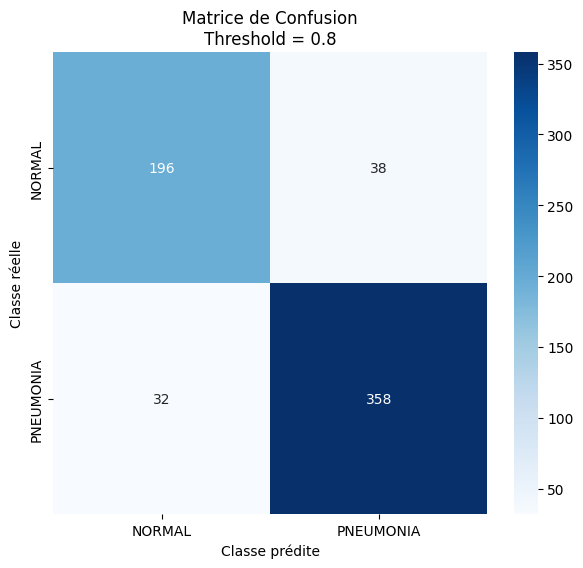


========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

      NORMAL       0.86      0.84      0.85       234
   PNEUMONIA       0.90      0.92      0.91       390

    accuracy                           0.89       624
   macro avg       0.88      0.88      0.88       624
weighted avg       0.89      0.89      0.89       624


========== F1-SCORE ==========

F1-score : 0.9109


In [17]:
# =========================================================
# CONFUSION MATRIX FINALE
# AVEC THRESHOLD OPTIMISE
# =========================================================

# =========================================================
# IMPORTATION DES BIBLIOTHEQUES
# =========================================================

from sklearn.metrics import (

    confusion_matrix,

    classification_report,

    f1_score
)

import seaborn as sns


# =========================================================
# THRESHOLD OPTIMISE
# =========================================================

best_threshold = 0.8


# =========================================================
# CONVERSION EN CLASSES
# =========================================================

predicted_labels = (

    predictions >= best_threshold

).astype(int)


# =========================================================
# SUPPRESSION DIMENSION INUTILE
# =========================================================

predicted_labels = predicted_labels.flatten()


# =========================================================
# MATRICE DE CONFUSION
# =========================================================

cm = confusion_matrix(

    true_labels,

    predicted_labels
)


# =========================================================
# AFFICHAGE MATRICE DE CONFUSION
# =========================================================

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot = True,

    fmt = "d",

    cmap = "Blues",

    xticklabels = [

        "NORMAL",

        "PNEUMONIA"
    ],

    yticklabels = [

        "NORMAL",

        "PNEUMONIA"
    ]
)

plt.title(

    f"Matrice de Confusion\nThreshold = {best_threshold}"
)

plt.xlabel("Classe prédite")

plt.ylabel("Classe réelle")

plt.show()

print("\n========== CLASSIFICATION REPORT ==========\n")

print(

    classification_report(

        true_labels,

        predicted_labels,

        target_names = [

            "NORMAL",

            "PNEUMONIA"
        ]
    )
)


# =========================================================
# F1-SCORE
# =========================================================

f1 = f1_score(

    true_labels,

    predicted_labels
)

print("\n========== F1-SCORE ==========\n")

print(f"F1-score : {f1:.4f}")

In [18]:
# =========================================================
# FINE TUNING DE DenseNet121
# =========================================================

# =========================================================
# DEBLOCAGE DU MODELE
# =========================================================

base_model.trainable = True


# =========================================================
# NOMBRE TOTAL DES COUCHES
# =========================================================

print("\n========== NOMBRE TOTAL DES COUCHES ==========\n")

print(len(base_model.layers))


# =========================================================
# GEL DES PREMIERES COUCHES
# =========================================================

fine_tune_at = 300

# =========================================================
# GEL PARTIEL
# =========================================================

for layer in base_model.layers[:fine_tune_at]:

    layer.trainable = False


# =========================================================
# AFFICHAGE INFORMATIONS
# =========================================================

print("\n========== FINE TUNING ==========\n")

print(f"Couches gelées : {fine_tune_at}")

print(f"Couches entraînables : {len(base_model.layers) - fine_tune_at}")


# =========================================================
# RECOMPILATION DU MODELE
# =========================================================

model.compile(


    # =====================================================
    # OPTIMIZER
    # =====================================================

    optimizer = tf.keras.optimizers.Adam(

        learning_rate = 0.00001
    ),


    # =====================================================
    # LOSS
    # =====================================================

    loss = "binary_crossentropy",


    # =====================================================
    # METRIQUES
    # =====================================================

    metrics = [

        "accuracy",

        Precision(name="precision"),

        Recall(name="recall"),

        AUC(name="auc")
    ]
)
print("\nFine Tuning configuré avec succès !")


========== NOMBRE TOTAL DES COUCHES ==========

427

========== FINE TUNING ==========

Couches gelées : 300
Couches entraînables : 127

Fine Tuning configuré avec succès !


In [19]:
# =========================================================
# ENTRAINEMENT DU FINE TUNING
# DenseNet121
# =========================================================

# =========================================================
# CALLBACK POUR REDUIRE LE LEARNING RATE
# =========================================================

from tensorflow.keras.callbacks import ReduceLROnPlateau


# =========================================================
# REDUCTION AUTOMATIQUE DU LEARNING RATE
# =========================================================

reduce_lr = ReduceLROnPlateau(


    # =====================================================
    # METRIQUE SURVEILLEE
    # =====================================================

    monitor = "val_loss",


    # =====================================================
    # FACTEUR DE REDUCTION
    # =====================================================

    factor = 0.2,


    # =====================================================
    # PATIENCE
    # =====================================================

    patience = 2,


    # =====================================================
    # LEARNING RATE MINIMUM
    # =====================================================

    min_lr = 1e-7,


    # =====================================================
    # AFFICHAGE
    # =====================================================

    verbose = 1
)


# =========================================================
# NOMBRE D'EPOCHS FINE TUNING
# =========================================================

fine_tune_epochs = 10


# =========================================================
# ENTRAINEMENT DU FINE TUNING
# =========================================================

history_fine = model.fit(


    # =====================================================
    # TRAIN DATASET
    # =====================================================

    train_dataset,


    # =====================================================
    # VALIDATION DATASET
    # =====================================================

    validation_data = val_dataset,


    # =====================================================
    # NOMBRE D'EPOCHS
    # =====================================================

    epochs = fine_tune_epochs,


    # =====================================================
    # CALLBACKS
    # =====================================================

    callbacks = [

        early_stopping,

        checkpoint,

        reduce_lr
    ],


    # =====================================================
    # VERBOSE
    # =====================================================

    verbose = 1
)

print("\nFine Tuning DenseNet121 terminé avec succès !")

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.9194 - auc: 0.9735 - loss: 0.1836 - precision: 0.9406 - recall: 0.9502
Epoch 1: val_loss improved from 0.14243 to 0.14086, saving model to best_densenet121_model.keras

Epoch 1: finished saving model to best_densenet121_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 62s 363ms/step - accuracy: 0.9185 - auc: 0.9704 - loss: 0.1922 - precision: 0.9383 - recall: 0.9523 - val_accuracy: 0.9434 - val_auc: 0.9863 - val_loss: 0.1409 - val_precision: 0.9829 - val_recall: 0.9421 - learning_rate: 1.0000e-05
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9326 - auc: 0.9767 - loss: 0.1745 - precision: 0.9523 - recall: 0.9559
Epoch 2: val_loss did not improve from 0.14086
131/131 ━━━━━━━━━━━━━━━━━━━━ 37s 279ms/step - accuracy: 0.9281 - auc: 0.9725 - loss: 0.1847 - precision: 0.9464 - recall: 0.9568 - val_accuracy: 0.9406 - val_auc: 0.9860 - val_loss: 0.1460 - val_precision: 0.9828 - val_recall: 0.9383 - learning_rate: 1

In [20]:
# =========================================================
# CHARGEMENT DU MEILLEUR MODELE
# APRES FINE TUNING
# =========================================================

from tensorflow.keras.models import load_model

# =========================================================
# CHARGEMENT DU MEILLEUR MODELE
# =========================================================

model = load_model(

    "best_densenet121_model.keras"
)

print("Meilleur modèle Fine Tuned DenseNet121 chargé avec succès !")

Meilleur modèle Fine Tuned DenseNet121 chargé avec succès !


In [21]:
# =========================================================
# EVALUATION FINALE APRES FINE TUNING
# DenseNet121
# =========================================================

# =========================================================
# EVALUATION SUR LE TEST SET
# =========================================================

test_results = model.evaluate(


    # =====================================================
    # TEST DATASET
    # =====================================================

    test_dataset,


    # =====================================================
    # VERBOSE
    # =====================================================

    verbose = 1
)


# =========================================================
# RECUPERATION DES NOMS DES METRIQUES
# =========================================================

metric_names = model.metrics_names

print("\n========== RESULTATS TEST SET ==========\n")


# =========================================================
# AFFICHAGE DETAILLE
# =========================================================

for name, value in zip(

    metric_names,

    test_results
):

    print(f"{name} : {value:.4f}")

print("\nEvaluation finale après Fine Tuning terminée avec succès !")

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 163ms/step - accuracy: 0.8526 - auc: 0.9475 - loss: 0.3668 - precision: 0.8225 - recall: 0.9744

========== RESULTATS TEST SET ==========

loss : 0.3668
compile_metrics : 0.8526

Evaluation finale après Fine Tuning terminée avec succès !


In [22]:
# =========================================================
# PREDICTIONS APRES FINE TUNING
# DenseNet121
# =========================================================

# =========================================================
# RECUPERATION DES VRAIS LABELS
# =========================================================

true_labels = np.concatenate([

    y for x, y in test_dataset

])


# =========================================================
# PREDICTIONS DU MODELE
# =========================================================

predictions = model.predict(

    test_dataset
)


# =========================================================
# SHAPE DES PREDICTIONS
# =========================================================

print("\n========== SHAPE PREDICTIONS ==========\n")

print(predictions.shape)


# =========================================================
# EXEMPLES DES PREDICTIONS
# =========================================================

print("\n========== EXEMPLES PREDICTIONS ==========\n")

print(predictions[:10])

print("\nPrédictions après Fine Tuning calculées avec succès !")

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 336ms/step

========== SHAPE PREDICTIONS ==========

(624, 1)

========== EXEMPLES PREDICTIONS ==========

[[0.24530515]
 [0.22577839]
 [0.675334  ]
 [0.518351  ]
 [0.27406505]
 [0.09789436]
 [0.46011502]
 [0.23641688]
 [0.7184223 ]
 [0.5768311 ]]

Prédictions après Fine Tuning calculées avec succès !


In [23]:
# =========================================================
# NOUVEAU THRESHOLD TUNING
# APRES FINE TUNING
# =========================================================

# =========================================================
# IMPORTATION DES BIBLIOTHEQUES
# =========================================================

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score
)

# =========================================================
# LISTE DES THRESHOLDS
# =========================================================

thresholds = np.arange(

    0.1,

    1.0,

    0.1
)


# =========================================================
# STOCKAGE DES RESULTATS
# =========================================================

results = []

# =========================================================
# TEST DES THRESHOLDS
# =========================================================

for threshold in thresholds:


    # =====================================================
    # CONVERSION EN CLASSES
    # =====================================================

    predicted_classes = (

        predictions >= threshold

    ).astype(int)


    # =====================================================
    # SUPPRESSION DIMENSION INUTILE
    # =====================================================

    predicted_classes = predicted_classes.flatten()


    # =====================================================
    # CALCUL DES METRIQUES
    # =====================================================

    accuracy = accuracy_score(

        true_labels,

        predicted_classes
    )


    precision = precision_score(

        true_labels,

        predicted_classes
    )


    recall = recall_score(

        true_labels,

        predicted_classes
    )


    f1 = f1_score(

        true_labels,

        predicted_classes
    )


    # =====================================================
    # STOCKAGE DES RESULTATS
    # =====================================================

    results.append([

        threshold,

        accuracy,

        precision,

        recall,

        f1
    ])


# =========================================================
# CREATION DU DATAFRAME
# =========================================================

results_df = pd.DataFrame(

    results,

    columns = [

        "Threshold",

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score"
    ]
)

print("\n========== RESULTATS THRESHOLDS ==========\n")

print(results_df)


========== RESULTATS THRESHOLDS ==========

   Threshold  Accuracy  Precision    Recall  F1-score
0        0.1  0.733974   0.702166  0.997436  0.824153
1        0.2  0.774038   0.737143  0.992308  0.845902
2        0.3  0.801282   0.764940  0.984615  0.860987
3        0.4  0.830128   0.794606  0.982051  0.878440
4        0.5  0.852564   0.822511  0.974359  0.892019
5        0.6  0.852564   0.834081  0.953846  0.889952
6        0.7  0.870192   0.861827  0.943590  0.900857
7        0.8  0.889423   0.904282  0.920513  0.912325
8        0.9  0.879808   0.933884  0.869231  0.900398


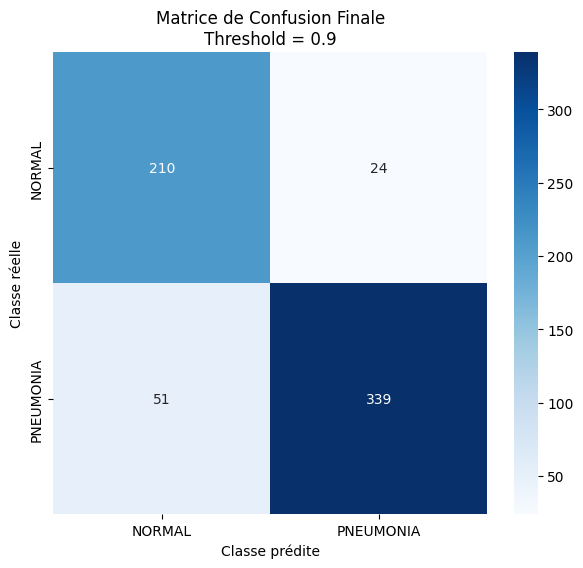


========== CLASSIFICATION REPORT FINAL ==========

              precision    recall  f1-score   support

      NORMAL       0.80      0.90      0.85       234
   PNEUMONIA       0.93      0.87      0.90       390

    accuracy                           0.88       624
   macro avg       0.87      0.88      0.87       624
weighted avg       0.89      0.88      0.88       624


========== F1-SCORE FINAL ==========

F1-score : 0.9004


In [24]:
# =========================================================
# CONFUSION MATRIX FINALE
# APRES FINE TUNING
# AVEC THRESHOLD = 0.9
# =========================================================

# =========================================================
# IMPORTATION DES BIBLIOTHEQUES
# =========================================================

from sklearn.metrics import (

    confusion_matrix,

    classification_report,

    f1_score
)

# =========================================================
# THRESHOLD FINAL
# =========================================================

best_threshold = 0.9


# =========================================================
# CONVERSION EN CLASSES
# =========================================================

predicted_labels = (

    predictions >= best_threshold

).astype(int)


# =========================================================
# SUPPRESSION DIMENSION INUTILE
# =========================================================

predicted_labels = predicted_labels.flatten()


# =========================================================
# MATRICE DE CONFUSION
# =========================================================

cm = confusion_matrix(

    true_labels,

    predicted_labels
)


# =========================================================
# AFFICHAGE MATRICE DE CONFUSION
# =========================================================

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot = True,

    fmt = "d",

    cmap = "Blues",

    xticklabels = [

        "NORMAL",

        "PNEUMONIA"
    ],

    yticklabels = [

        "NORMAL",

        "PNEUMONIA"
    ]
)

plt.title(

    f"Matrice de Confusion Finale\nThreshold = {best_threshold}"
)

plt.xlabel("Classe prédite")

plt.ylabel("Classe réelle")

plt.show()

print("\n========== CLASSIFICATION REPORT FINAL ==========\n")

print(

    classification_report(

        true_labels,

        predicted_labels,

        target_names = [

            "NORMAL",

            "PNEUMONIA"
        ]
    )
)


# =========================================================
# F1-SCORE FINAL
# =========================================================

f1 = f1_score(

    true_labels,

    predicted_labels
)


print("\n========== F1-SCORE FINAL ==========\n")

print(f"F1-score : {f1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


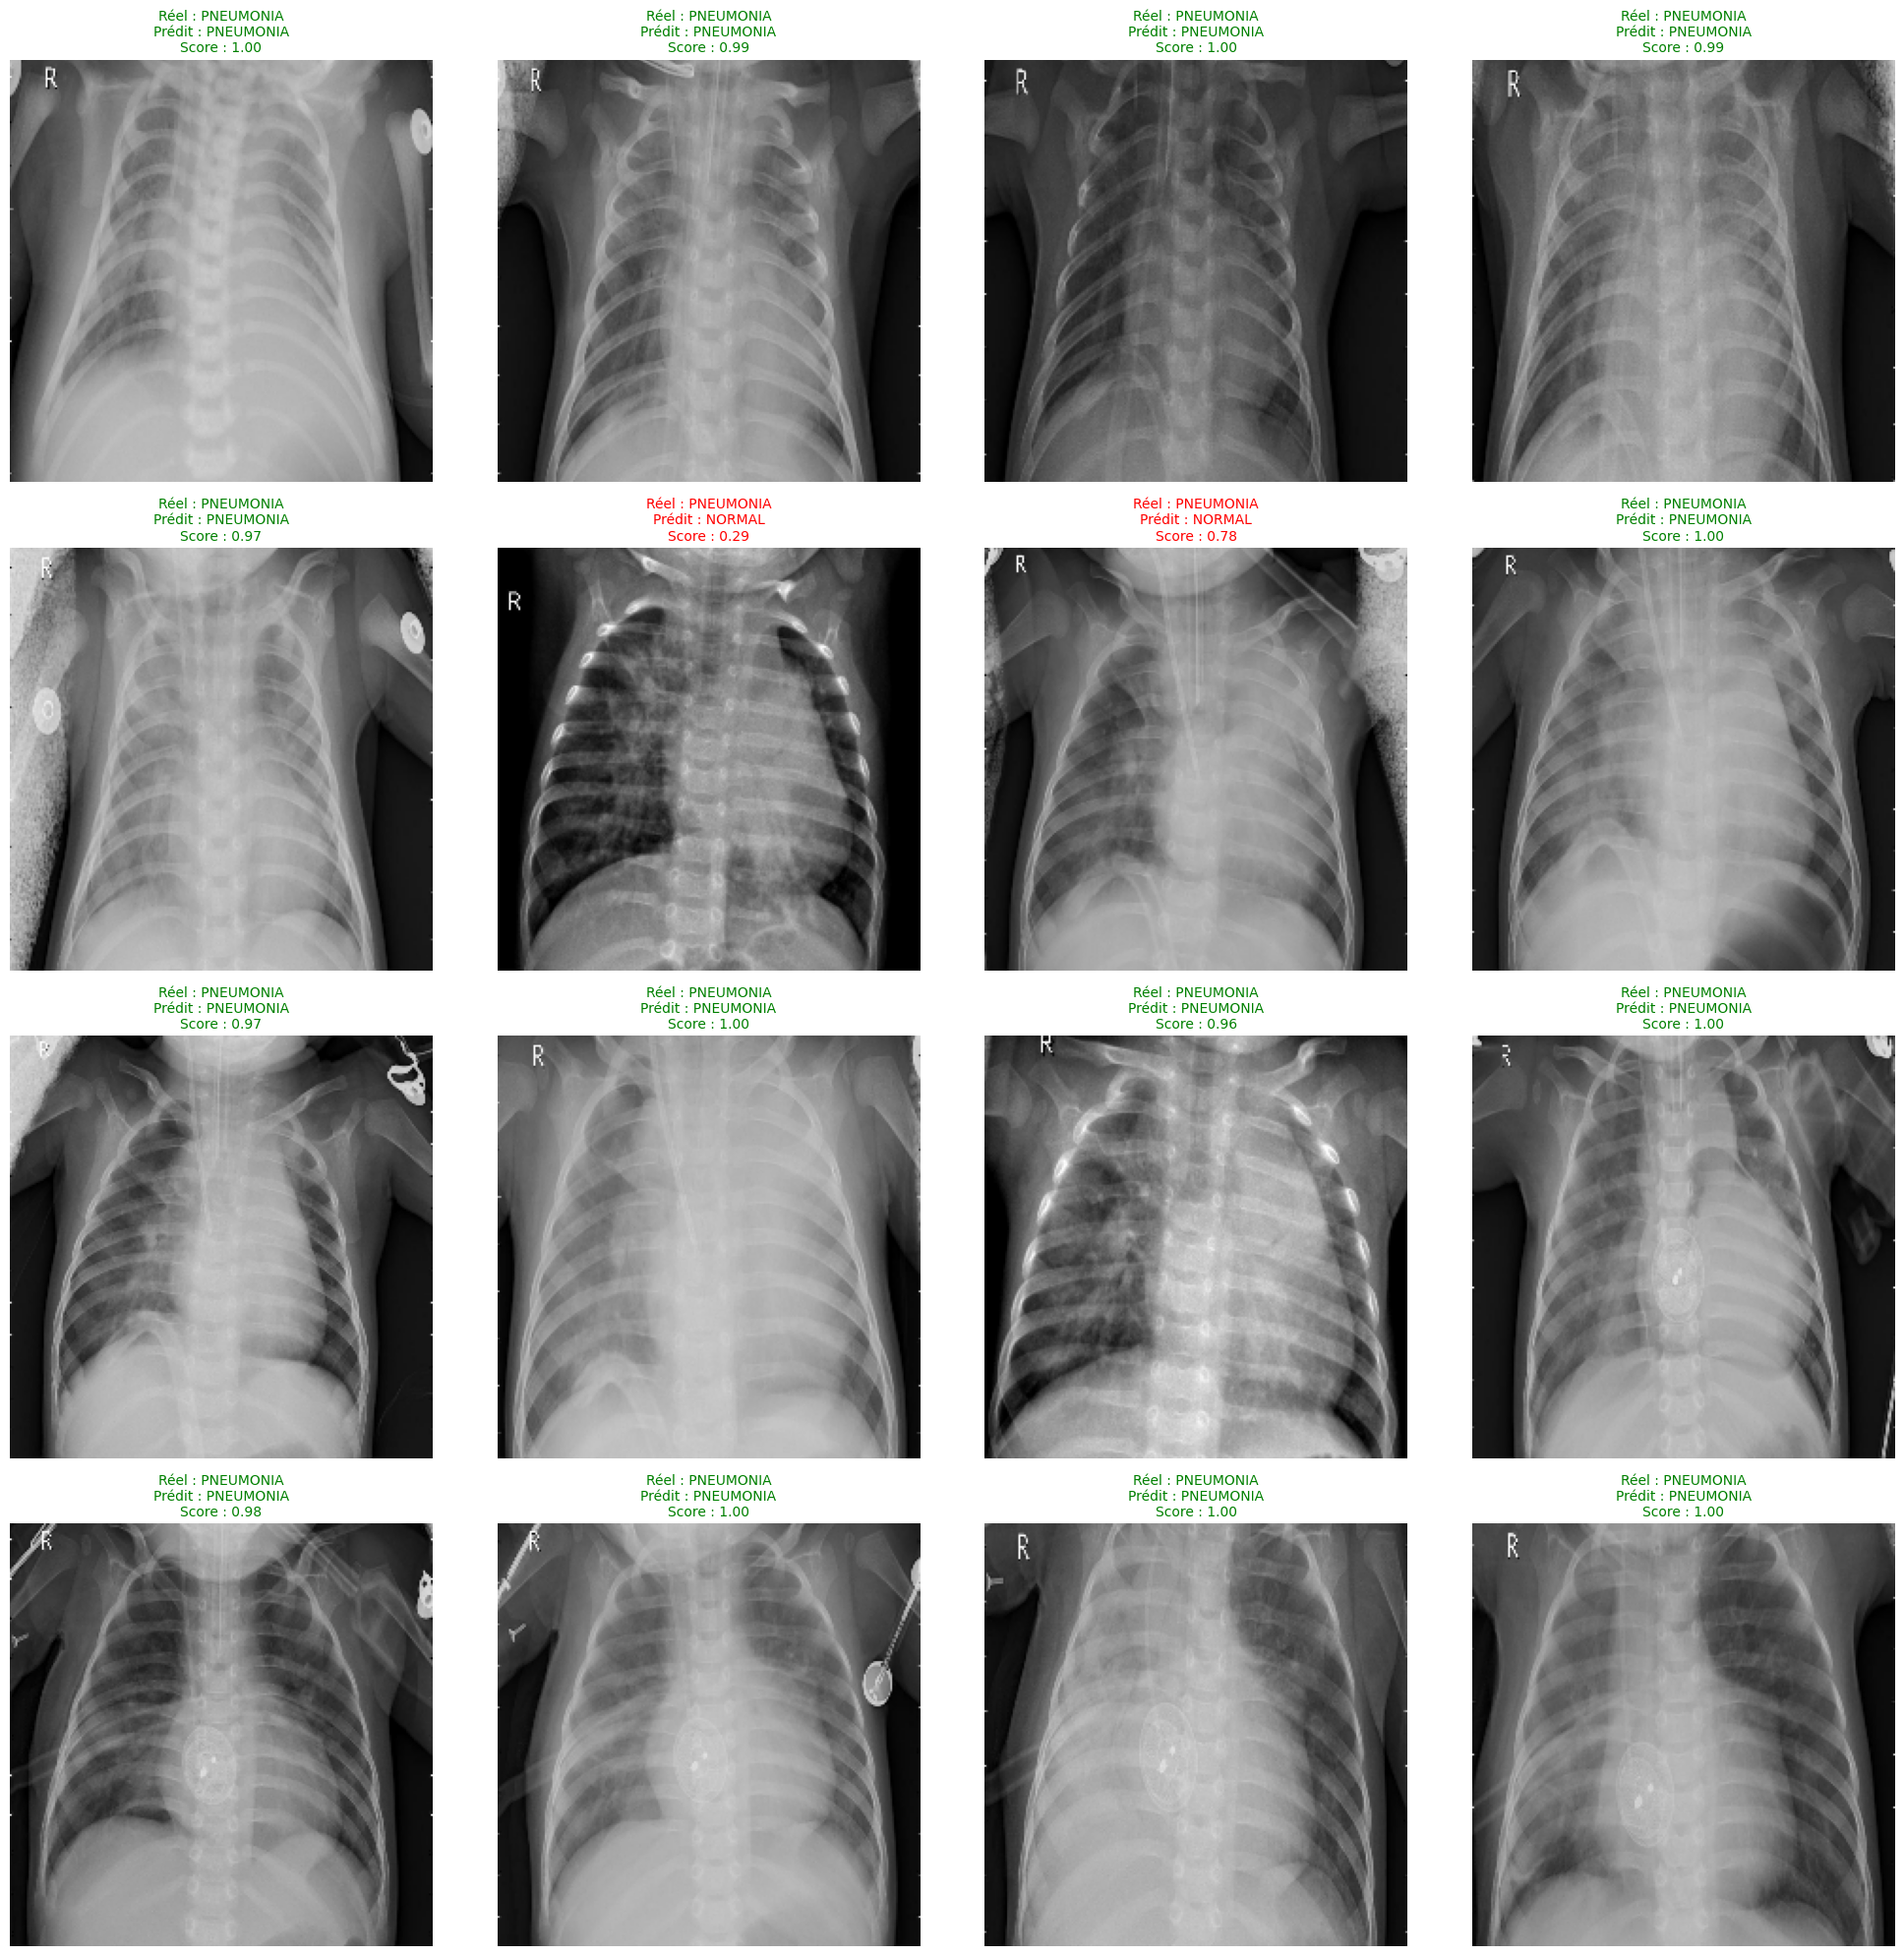

In [27]:
# =========================================================
# TEST FINAL DU MODELE
# AVEC MELANGE D'IMAGES
# NORMAL + PNEUMONIA
# =========================================================


# =========================================================
# NOMS DES CLASSES
# =========================================================

class_names = [

    "NORMAL",

    "PNEUMONIA"
]


# =========================================================
# THRESHOLD FINAL
# =========================================================

best_threshold = 0.9


# =========================================================
# MELANGE ALEATOIRE DU TEST DATASET
# =========================================================

shuffled_dataset = test_dataset.shuffle(

    buffer_size = 1000
)


# =========================================================
# RECUPERATION D'UN BATCH
# =========================================================

for images, labels in shuffled_dataset.take(1):


    # =====================================================
    # PREDICTIONS
    # =====================================================

    predictions = model.predict(

        images
    )


    # =====================================================
    # CONVERSION EN CLASSES
    # =====================================================

    predicted_labels = (

        predictions >= best_threshold

    ).astype(int)


    # =====================================================
    # CREATION FIGURE
    # =====================================================

    plt.figure(figsize=(20,20))


    # =====================================================
    # AFFICHAGE DE 16 IMAGES
    # =====================================================

    for i in range(16):

        plt.subplot(4,4,i+1)

        plt.imshow(

         (images[i].numpy() * 255).astype("uint8")
      )


        # =================================================
        # VRAI LABEL
        # =================================================

        true_label = int(

            labels[i].numpy()[0]
        )


        predicted_label = int(

            predicted_labels[i][0]
        )


        # =================================================
        # NOMS DES CLASSES
        # =================================================

        true_class = class_names[true_label]

        predicted_class = class_names[predicted_label]


        # =================================================
        # PROBABILITE
        # =================================================

        probability = predictions[i][0]


        # =================================================
        # COULEUR TITRE
        # =================================================

        if true_label == predicted_label:

            color = "green"

        else:

            color = "red"

        plt.title(

            f"Réel : {true_class}\n"
            f"Prédit : {predicted_class}\n"
            f"Score : {probability:.2f}",

            color = color,

            fontsize = 10
        )


        # =================================================
        # SUPPRESSION DES AXES
        # =================================================

        plt.axis("off")

    plt.tight_layout()


    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


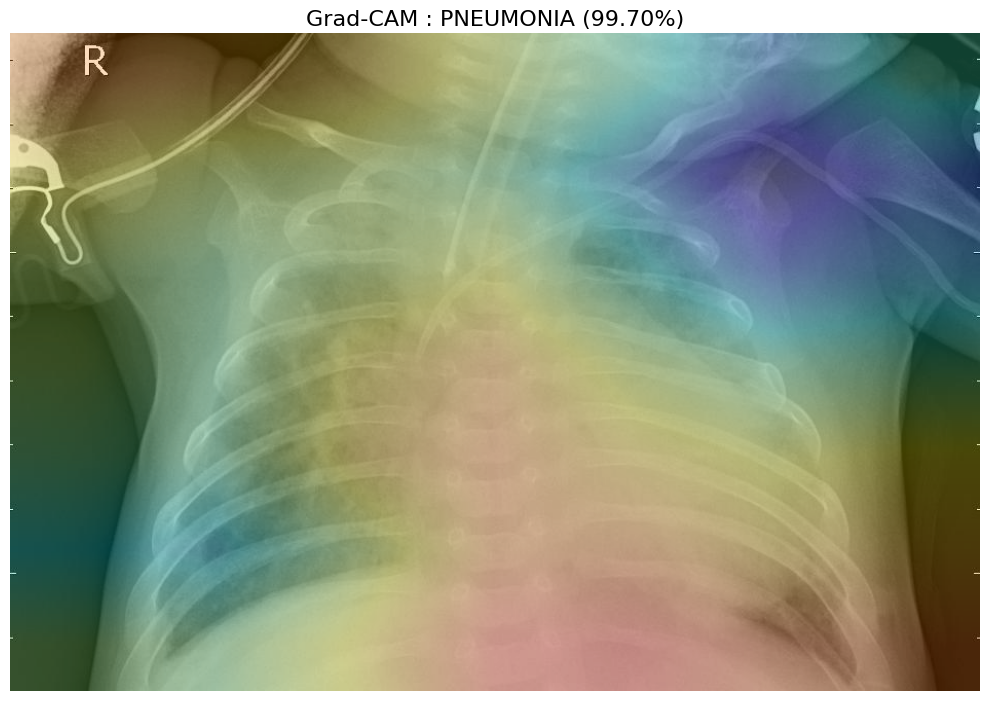


========== RESULTAT FINAL ==========

Probabilité : 0.9970
Classe prédite : PNEUMONIA


In [28]:
# =========================================================
# GRAD-CAM FINAL PROPRE
# DenseNet121
# =========================================================

import cv2

from tensorflow.keras.preprocessing import image


# =========================================================
# CHEMIN IMAGE
# =========================================================

img_path = "/content/chest_xray/chest_xray/test/PNEUMONIA/person1_virus_6.jpeg"


# =========================================================
# CHARGEMENT IMAGE
# =========================================================

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)


# =========================================================
# DERNIERE COUCHE CONVOLUTION
# =========================================================

last_conv_layer_name = "conv5_block16_concat"


# =========================================================
# RECUPERATION DenseNet121
# =========================================================

densenet_model = model.get_layer(
    "densenet121"
)


# =========================================================
# MODELE GRAD-CAM
# =========================================================

grad_model = tf.keras.models.Model(
    inputs=densenet_model.input,

    outputs=[
        densenet_model.get_layer(
            last_conv_layer_name
        ).output,

        densenet_model.output
    ]
)


# =========================================================
# PASSAGE IMAGE DANS DenseNet121
# =========================================================

processed_img = model.layers[1](
    img_array
)


# =========================================================
# CALCUL DES GRADIENTS
# =========================================================

with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(
        processed_img
    )

    loss = predictions[:, 0]


# =========================================================
# GRADIENTS
# =========================================================

grads = tape.gradient(
    loss,
    conv_outputs
)


# =========================================================
# MOYENNE DES GRADIENTS
# =========================================================

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)


# =========================================================
# FEATURE MAPS
# =========================================================

conv_outputs = conv_outputs[0]


# =========================================================
# CREATION HEATMAP
# =========================================================

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

heatmap = tf.squeeze(
    heatmap
)


# =========================================================
# NORMALISATION
# =========================================================

heatmap = tf.maximum(
    heatmap,
    0
) / tf.math.reduce_max(
    heatmap
)

heatmap = heatmap.numpy()

original_img = cv2.imread(
    img_path
)

original_img = cv2.cvtColor(
    original_img,
    cv2.COLOR_BGR2RGB
)


# =========================================================
# REDIMENSION HEATMAP
# =========================================================

heatmap = cv2.resize(
    heatmap,

    (
        original_img.shape[1],
        original_img.shape[0]
    )
)


# =========================================================
# CONVERSION UINT8
# =========================================================

heatmap = np.uint8(
    255 * heatmap
)


# =========================================================
# LISSAGE HEATMAP
# =========================================================

heatmap = cv2.GaussianBlur(
    heatmap,
    (15,15),
    0
)


# =========================================================
# APPLICATION COLORMAP
# =========================================================

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)


# =========================================================
# SUPERPOSITION AMELIOREE
# =========================================================

superimposed_img = cv2.addWeighted(

    original_img,
    0.75,

    heatmap,
    0.25,

    0
)


# =========================================================
# PREDICTION COMPLETE
# =========================================================

prediction = model.predict(
    img_array
)

probability = prediction[0][0]


# =========================================================
# CLASSE PREDITE
# =========================================================

if probability >= 0.9:

    predicted_class = "PNEUMONIA"

else:

    predicted_class = "NORMAL"


# =========================================================
# AFFICHAGE FINAL
# =========================================================

plt.figure(figsize=(10,10))

plt.imshow(
    superimposed_img
)

plt.title(
    f"Grad-CAM : {predicted_class} ({probability:.2%})",
    fontsize=16
)

plt.axis("off")

plt.tight_layout()

plt.show()

print("\n========== RESULTAT FINAL ==========\n")

print(f"Probabilité : {probability:.4f}")

print(f"Classe prédite : {predicted_class}")

In [29]:
from google.colab import files

files.download("best_densenet121_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>